In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model

import joblib

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.shape

(1025, 14)

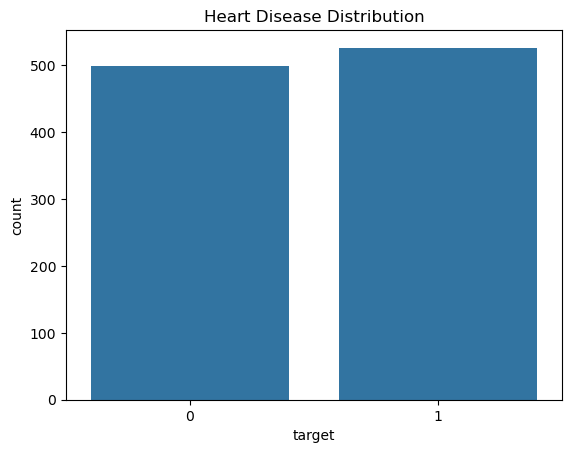

In [9]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

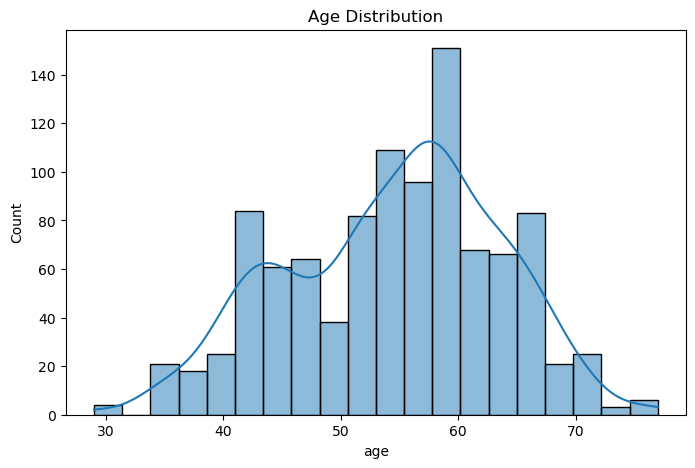

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

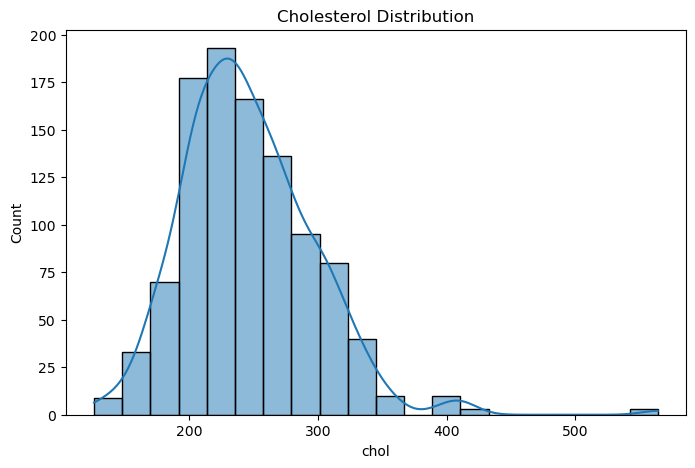

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['chol'], bins=20, kde=True)
plt.title('Cholesterol Distribution')
plt.show()

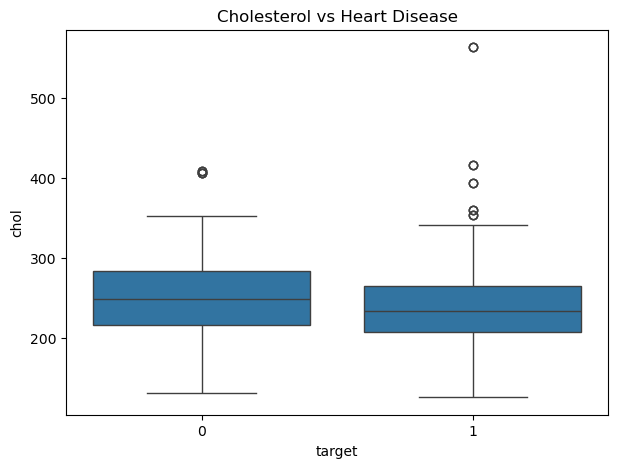

In [8]:
plt.figure(figsize=(7,5))
sns.boxplot(x='target', y='chol', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.show()

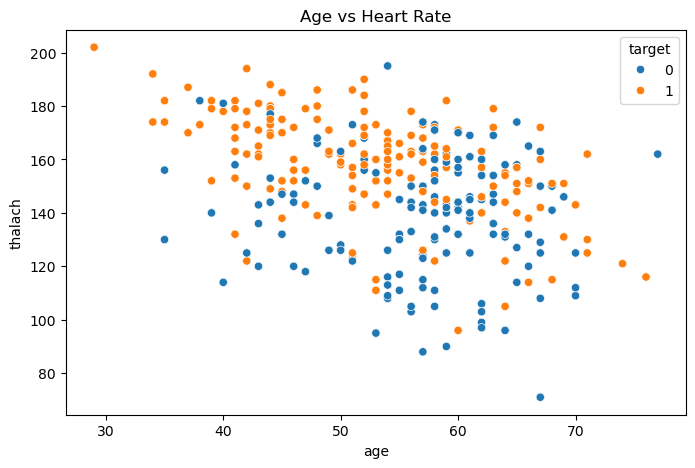

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title('Age vs Heart Rate')
plt.show()

In [10]:
X = df.drop('target', axis=1)
y = df['target']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
joblib.dump(scaler, 'heart_scaler.pkl')

print("Scaler saved successfully.")

Scaler saved successfully.


In [15]:
model = Sequential()

In [16]:
model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.add(Dense(16, activation='relu'))

In [18]:
model.add(Dense(8, activation='relu'))

In [19]:
model.add(Dense(1, activation='sigmoid'))

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5793 - loss: 0.6580 - val_accuracy: 0.6829 - val_loss: 0.6094
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8034 - loss: 0.5337 - val_accuracy: 0.7744 - val_loss: 0.5243
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8567 - loss: 0.4336 - val_accuracy: 0.8049 - val_loss: 0.4578
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8689 - loss: 0.3589 - val_accuracy: 0.8049 - val_loss: 0.4244
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8796 - loss: 0.3219 - val_accuracy: 0.8049 - val_loss: 0.4137
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8872 - loss: 0.2991 - val_accuracy: 0.8049 - val_loss: 0.4057
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8872 - loss: 0.2834 - val_accuracy: 0.7927 - val_loss: 0.3994
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8933 - loss: 0.2705 - val_accuracy: 0.8232 - val_lo

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9512 - loss: 0.1226
Test Accuracy: 0.9512194991111755


In [24]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       102
           1       0.95      0.95      0.95       103

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



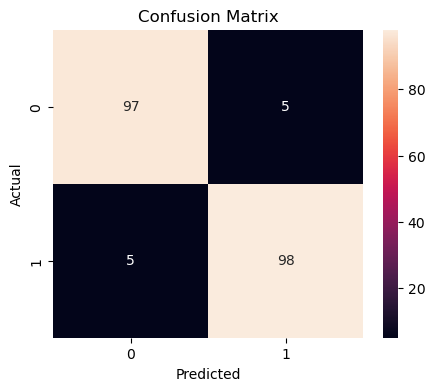

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
model.save('heart_disease_ann_model.h5')

print("Heart Disease Model saved successfully.")

Heart Disease Model saved successfully.


In [27]:
loaded_model = load_model('heart_disease_ann_model.h5')

print("Model loaded successfully.")

Model loaded successfully.


In [28]:
sample_data = np.array([[52,1,0,125,212,0,1,168,0,1.0,2,2,3]])

In [29]:
sample_data = scaler.transform(sample_data)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [30]:
prediction = loaded_model.predict(sample_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


In [31]:
print(prediction)

if prediction[0][0] > 0.5:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

[[0.00015398]]
No Heart Disease
